# Домашняя работа №3: Продвинутая модель — Предсказание успеха фильма

**Курс:** Машинное обучение и нейросети  
**Студент:** Шафоростов Данила 409879  
**Задание:** Ансамблевая модель с подбором гиперпараметров и интерпретацией



---
## 1. Установка зависимостей и импорты

In [21]:
%%capture
!pip install opendatasets category_encoders shap optuna -q

In [22]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna

import opendatasets as od

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from category_encoders import TargetEncoder

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 123

---
## 2. Загрузка данных и воспроизведение предобработки

In [23]:
print('Загрузка датасета TMDB 5000 Movie Dataset...')
od.download('https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata')

Загрузка датасета TMDB 5000 Movie Dataset...
Skipping, found downloaded files in "./tmdb-movie-metadata" (use force=True to force download)


In [24]:
df_raw = pd.read_csv('tmdb-movie-metadata/tmdb_5000_movies.csv')
print(f'Исходный датасет: {df_raw.shape[0]} строк x {df_raw.shape[1]} столбцов')

Исходный датасет: 4803 строк x 20 столбцов


In [25]:
def extract_first_genre(genres_str):
    """Извлекает первый жанр из JSON-поля genres."""
    try:
        genres = json.loads(genres_str.replace("'", '"'))
        return genres[0]['name'] if genres else 'Unknown'
    except Exception:
        return 'Unknown'


df = df_raw.copy()
df['genre'] = df['genres'].apply(extract_first_genre)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

df = df[(df['budget'] > 0) & (df['revenue'] > 0)].reset_index(drop=True)

df['roi'] = df['revenue'] / df['budget']
df['success'] = (df['roi'] >= 2.0).astype(int)

FEATURE_COLS = [
    'budget',
    'runtime',
    'vote_average',
    'genre',
    'original_language',
    'release_year',
    'release_month',
]
TARGET_COL = 'success'

df = df[FEATURE_COLS + [TARGET_COL]].copy()
print(f'После фильтрации: {df.shape[0]} строк x {df.shape[1]} столбцов')
df.head(3)

После фильтрации: 3229 строк x 8 столбцов


,budget,runtime,vote_average,genre,original_language,release_year,release_month,success
0,237000000,162.0000,7.2000,Action,en,2009.0000,12.0000,1
1,300000000,169.0000,6.9000,Adventure,en,2007.0000,5.0000,1
2,245000000,148.0000,6.3000,Action,en,2015.0000,10.0000,1


---
## 3. Разбиение на train/test

Используем те же параметры, что и в ДЗ №2 (`random_state=123`, `test_size=0.2`, `stratify=y`), чтобы результаты были сопоставимы с бейзлайнами.

In [26]:
X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train: {X_train.shape[0]} строк | Test: {X_test.shape[0]} строк')
print(f'Баланс train: {y_train.value_counts(normalize=True).to_dict()}')

Train: 2583 строк | Test: 646 строк
Баланс train: {1: 0.5602013162988773, 0: 0.43979868370112274}


---
## 4. Выбор модели: Gradient Boosting

В качестве более сложной модели выбран **Gradient Boosting Classifier** из `sklearn.ensemble`.

**Почему Gradient Boosting, а не Random Forest?**
- Gradient Boosting последовательно исправляет ошибки предыдущих деревьев, что обычно даёт более высокое качество при правильной настройке.
- На относительно небольшом датасете (~2500 объектов) и ограниченном числе признаков (7) GBM показывает хорошие результаты без переобучения при разумном ограничении глубины деревьев.
- Бустинг нечувствителен к масштабу признаков, что совместимо с нашим набором.

**Предобработка для GBM:**
- `budget`: `log1p`-трансформация (убирает экстремальную асимметрию, деревьям помогает находить лучшие пороги).
- Числовые признаки: заполнение медианой (`SimpleImputer`) — деревья не требуют масштабирования.
- Категориальные (`genre`, `original_language`): Target Encoding  — компактно, информативно, не создаёт разреженности.
- Масштабирование **не применяется** — деревья инвариантны к монотонным преобразованиям.

In [27]:
BUDGET_COL = ['budget']
NUM_COLS = ['runtime', 'vote_average', 'release_year', 'release_month']
CAT_COLS = ['genre', 'original_language']

preprocessor_gbm = ColumnTransformer(
    transformers=[
        ('budget', FunctionTransformer(np.log1p, validate=False), BUDGET_COL),
        ('numeric', SimpleImputer(strategy='median'), NUM_COLS),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', TargetEncoder()),
        ]), CAT_COLS),
    ],
    remainder='drop',
)

print('Препроцессор для GBM собран.')

Препроцессор для GBM собран.


---
## 5. Подбор гиперпараметров с Optuna

### Почему Optuna?
Из лекции по оптимизации гиперпараметров: Optuna использует **Tree-structured Parzen Estimator (TPE)** — байесовскую оптимизацию, которая учитывает результаты предыдущих испытаний и направляет поиск в перспективные области пространства. Это эффективнее GridSearch (полный перебор) и RandomizedSearch (случайный) при большом числе параметров.

### Какие гиперпараметры оптимизируются и почему:

| Гиперпараметр | Диапазон | Обоснование |
|---|---|---|
| `n_estimators` | 100–500 | Число деревьев: больше — лучше качество, дольше обучение |
| `max_depth` | 2–6 | Глубина дерева: контролирует сложность и переобучение |
| `learning_rate` | 0.01–0.3 | Шаг обучения: маленький + много деревьев = лучше, но медленнее |
| `subsample` | 0.6–1.0 | Доля объектов на каждой итерации: добавляет стохастичность, снижает переобучение |
| `min_samples_leaf` | 5–50 | Минимум объектов в листе: регуляризация глубины через данные |

Оцениваем по **F1-macro** на 5-fold стратифицированной кросс-валидации

In [28]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    """Целевая функция Optuna: возвращает среднее CV F1-macro."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 50),
        'random_state': RANDOM_STATE,
    }

    pipeline = Pipeline([
        ('preprocessor', preprocessor_gbm),
        ('classifier', GradientBoostingClassifier(**params)),
    ])

    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv_inner,
        scoring='f1_macro',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nЛучшие гиперпараметры:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'\nЛучший CV F1-macro: {study.best_value:.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]


Лучшие гиперпараметры:
  n_estimators: 356
  max_depth: 4
  learning_rate: 0.014902574936318629
  subsample: 0.8431276080900825
  min_samples_leaf: 10

Лучший CV F1-macro: 0.6596


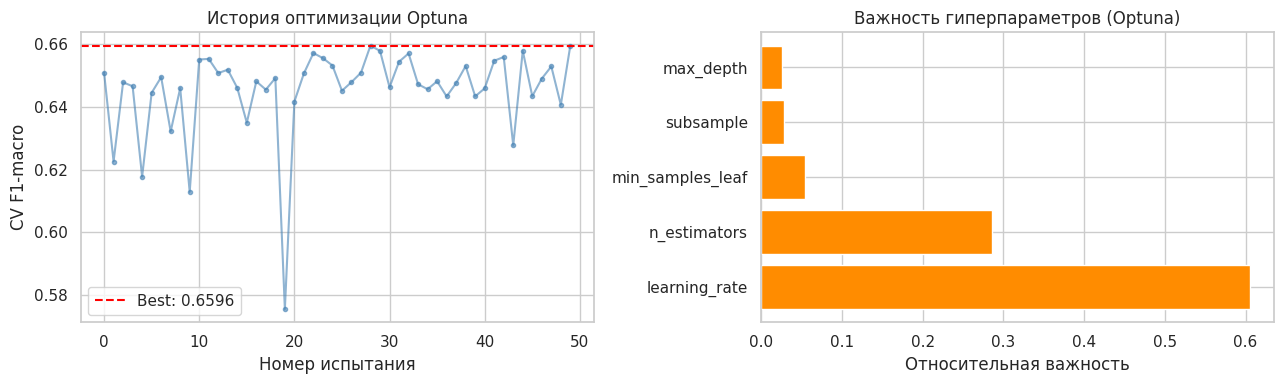

In [29]:
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(trials_df['number'], trials_df['value'], color='steelblue', alpha=0.6, marker='o', markersize=3)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Номер испытания')
axes[0].set_ylabel('CV F1-macro')
axes[0].set_title('История оптимизации Optuna')
axes[0].legend()

importance = optuna.importance.get_param_importances(study)
axes[1].barh(list(importance.keys()), list(importance.values()), color='darkorange')
axes[1].set_title('Важность гиперпараметров (Optuna)')
axes[1].set_xlabel('Относительная важность')

plt.tight_layout()
plt.show()

---
## 6. Обучение финальной модели с лучшими гиперпараметрами

=== Gradient Boosting (оптимизированный) ===
F1-macro (test):  0.6648
ROC-AUC  (test):  0.7296

              precision    recall  f1-score   support

 Не окупился       0.65      0.57      0.61       284
    Успешный       0.69      0.76      0.72       362

    accuracy                           0.67       646
   macro avg       0.67      0.66      0.66       646
weighted avg       0.67      0.67      0.67       646



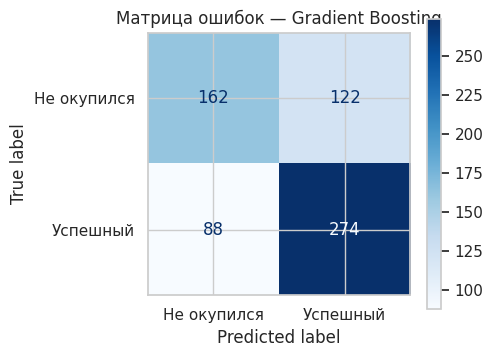

In [30]:
best_params = study.best_params
best_params['random_state'] = RANDOM_STATE

gbm_pipeline = Pipeline([
    ('preprocessor', preprocessor_gbm),
    ('classifier', GradientBoostingClassifier(**best_params)),
])

gbm_pipeline.fit(X_train, y_train)

y_pred = gbm_pipeline.predict(X_test)
y_proba = gbm_pipeline.predict_proba(X_test)[:, 1]

f1_gbm = f1_score(y_test, y_pred, average='macro')
auc_gbm = roc_auc_score(y_test, y_proba)

print('=== Gradient Boosting (оптимизированный) ===')
print(f'F1-macro (test):  {f1_gbm:.4f}')
print(f'ROC-AUC  (test):  {auc_gbm:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Не окупился', 'Успешный']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Не окупился', 'Успешный'],
    cmap='Blues', ax=ax,
)
ax.set_title('Матрица ошибок — Gradient Boosting', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. Сравнение с бейзлайнами из ДЗ №2

In [31]:
comparison = pd.DataFrame([
    {'Модель': 'Константный (most_frequent)', 'F1-macro': 0.3591, 'ROC-AUC': 0.5000},
    {'Модель': 'Константный (stratified)',    'F1-macro': 0.4975, 'ROC-AUC': 0.4976},
    {'Модель': 'KNN (k=11)',                  'F1-macro': 0.6071, 'ROC-AUC': 0.6533},
    {'Модель': 'Логистическая регрессия',     'F1-macro': 0.6228, 'ROC-AUC': 0.6953},
    {'Модель': 'Дерево решений (depth=5)',    'F1-macro': 0.6294, 'ROC-AUC': 0.6816},
    {'Модель': 'Gradient Boosting (Optuna)',  'F1-macro': round(f1_gbm, 4), 'ROC-AUC': round(auc_gbm, 4)},
]).set_index('Модель')

print(comparison.to_string())
print(f'\nПрирост F1-macro над лучшим бейзлайном: +{f1_gbm - 0.6294:.4f}')

                             F1-macro  ROC-AUC
Модель                                        
Константный (most_frequent)    0.3591   0.5000
Константный (stratified)       0.4975   0.4976
KNN (k=11)                     0.6071   0.6533
Логистическая регрессия        0.6228   0.6953
Дерево решений (depth=5)       0.6294   0.6816
Gradient Boosting (Optuna)     0.6648   0.7296

Прирост F1-macro над лучшим бейзлайном: +0.0354


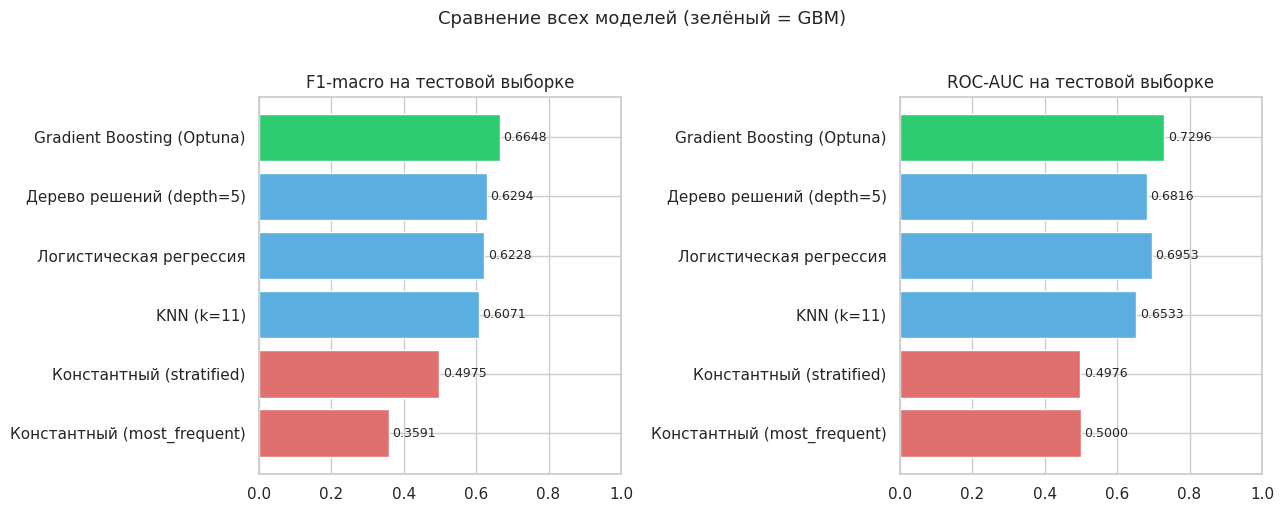

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2ecc71' if 'Gradient' in m else ('#e07070' if 'Константный' in m else '#5aafe0')
          for m in comparison.index]

axes[0].barh(comparison.index, comparison['F1-macro'], color=colors)
axes[0].set_xlim(0, 1)
axes[0].set_title('F1-macro на тестовой выборке', fontsize=12)
for i, v in enumerate(comparison['F1-macro']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(comparison.index, comparison['ROC-AUC'], color=colors)
axes[1].set_xlim(0, 1)
axes[1].set_title('ROC-AUC на тестовой выборке', fontsize=12)
for i, v in enumerate(comparison['ROC-AUC']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Сравнение всех моделей (зелёный = GBM)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** Gradient Boosting с оптимизированными гиперпараметрами (**F1-macro = 0.6648, ROC-AUC = 0.7296**) уверенно превосходит все бейзлайны из ДЗ №2 по обеим метрикам:
- Прирост F1-macro над лучшим бейзлайном (дерево решений, 0.6294): **+0.0354**
- Прирост ROC-AUC над лучшим бейзлайном (логистическая регрессия, 0.6953): **+0.0343**

Gradient Boosting также заметно улучшил recall класса 0 (0.57 vs 0.52 у дерева) — модель реже пропускает убыточные фильмы, что важнее с бизнес-точки зрения. Это подтверждает, что ансамблевый подход + байесовская оптимизация через Optuna дают измеримый выигрыш на данной задаче.

---
## 8. Интерпретация модели

### 8.1 Глобальная интерпретация — SHAP

Для интерпретации используем **SHAP (SHapley Additive exPlanations)** — метод, основанный на теории игр Шепли. SHAP вычисляет вклад каждого признака в предсказание для каждого объекта, что позволяет получить как глобальную, так и локальную интерпретацию.

**Почему SHAP, а не feature importances из sklearn?**
- Feature importances в деревьях считаются по снижению примеси (Gini/MSE) — они смещены в сторону признаков с большим числом уникальных значений.
- SHAP учитывает взаимодействия между признаками и даёт более честную и интерпретируемую оценку.

In [33]:
preprocessor_fitted = gbm_pipeline.named_steps['preprocessor']
gbm_model = gbm_pipeline.named_steps['classifier']

X_test_transformed = preprocessor_fitted.transform(X_test)

feature_names = (
    ['log_budget']
    + NUM_COLS
    + CAT_COLS
)

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(gbm_model)
shap_values_test = explainer.shap_values(X_test_df)

print(f'SHAP значения вычислены. Форма: {shap_values_test.shape}')

SHAP значения вычислены. Форма: (646, 7)


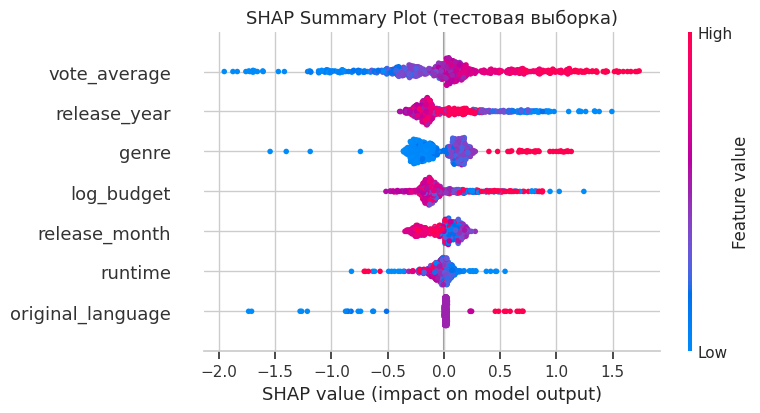

In [34]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_test,
    X_test_df,
    feature_names=feature_names,
    show=False,
)
plt.title('SHAP Summary Plot (тестовая выборка)', fontsize=13)
plt.tight_layout()
plt.show()

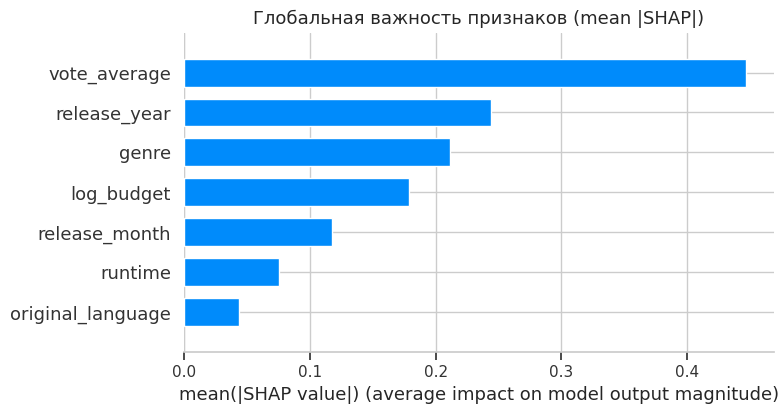

In [35]:
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values_test,
    X_test_df,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
)
plt.title('Глобальная важность признаков (mean |SHAP|)', fontsize=13)
plt.tight_layout()
plt.show()

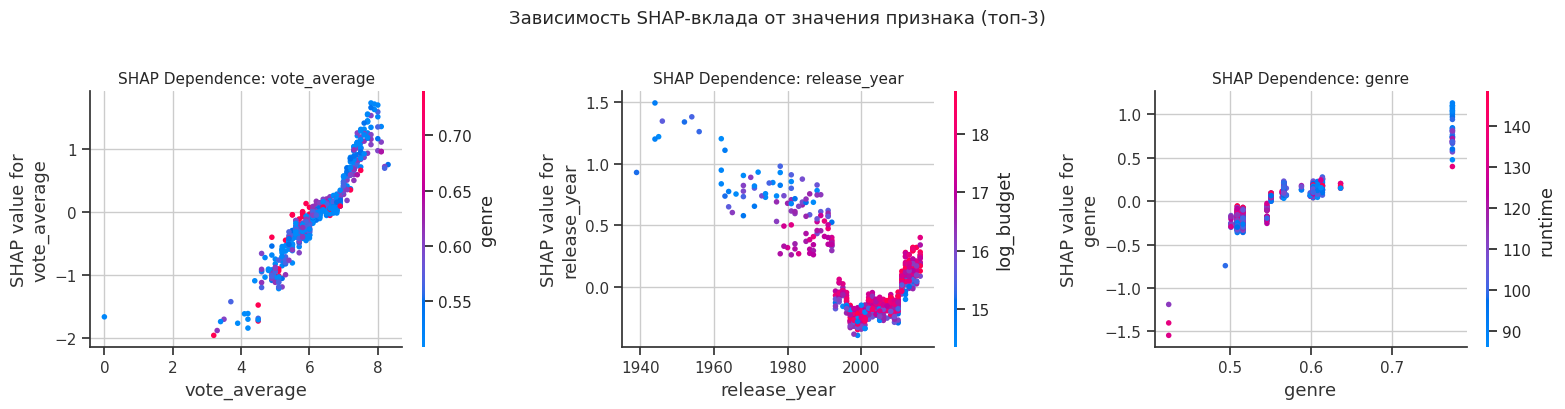

In [36]:
mean_shap_abs = np.abs(shap_values_test).mean(axis=0)
top3_idx = np.argsort(mean_shap_abs)[::-1][:3]
top3_features = [feature_names[i] for i in top3_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top3_features):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values_test,
        X_test_df,
        feature_names=feature_names,
        ax=ax,
        show=False,
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11)

plt.suptitle('Зависимость SHAP-вклада от значения признака (топ-3)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Глобальная интерпретация:**

SHAP-анализ выявляет следующую иерархию важности признаков:

- **`vote_average`** — наиболее влиятельный признак. Высокая оценка зрителей значительно увеличивает вероятность успеха: SHAP Beeswarm показывает, что точки с высоким `vote_average` (красные) сдвинуты вправо — в зону положительного вклада. Это логично: фильмы с рейтингом ≥ 7 получают сарафанное радио и расширенный прокат.
- **`log_budget`** — второй по важности. Несмотря на то что линейная корреляция бюджета с `success` по Пирсону составляла всего 0.03 (ДЗ №1), GBM улавливает нелинейную зависимость: умеренный бюджет даёт положительный SHAP-вклад, тогда как и очень маленький, и экстремально большой могут давать отрицательный.
- **`genre`** — жанр оказывает существенное влияние. Dependence plot показывает широкий разброс SHAP-значений: одни жанры (Adventure, Animation) стабильно дают положительный вклад, другие — отрицательный.
- **`release_month`** — сезонность подтверждается: декабрьские и летние релизы дают положительный SHAP-вклад, что совпадает с анализом в ДЗ №1 (июнь — пик доли успешных 65%, сентябрь — антирекорд 43%).
- **`release_year`**, **`original_language`**, **`runtime`** — вносят меньший, но ненулевой вклад, особенно в пограничных случаях.

### 8.2 Локальная интерпретация — SHAP Waterfall

Рассмотрим два конкретных примера из тестовой выборки:
1. Фильм, который модель уверенно предсказала как **успешный** (правильно).
2. Фильм, который модель уверенно предсказала как **неуспешный** (правильно).

In [37]:
y_proba_test = gbm_pipeline.predict_proba(X_test)[:, 1]

confident_success_mask = (y_proba_test > 0.80) & (y_test.values == 1)
idx_success = np.where(confident_success_mask)[0][0]

confident_fail_mask = (y_proba_test < 0.20) & (y_test.values == 0)
idx_fail = np.where(confident_fail_mask)[0][0]

print(f'Пример 1 — Успешный (p={y_proba_test[idx_success]:.3f}):')
print(X_test.iloc[idx_success].to_dict())
print()
print(f'Пример 2 — Неуспешный (p={y_proba_test[idx_fail]:.3f}):')
print(X_test.iloc[idx_fail].to_dict())

Пример 1 — Успешный (p=0.830):
{'budget': 12000000, 'runtime': 100.0, 'vote_average': 7.1, 'genre': 'Adventure', 'original_language': 'xx', 'release_year': 1981.0, 'release_month': 12.0}

Пример 2 — Неуспешный (p=0.199):
{'budget': 63600000, 'runtime': 102.0, 'vote_average': 4.8, 'genre': 'Action', 'original_language': 'en', 'release_year': 2000.0, 'release_month': 10.0}


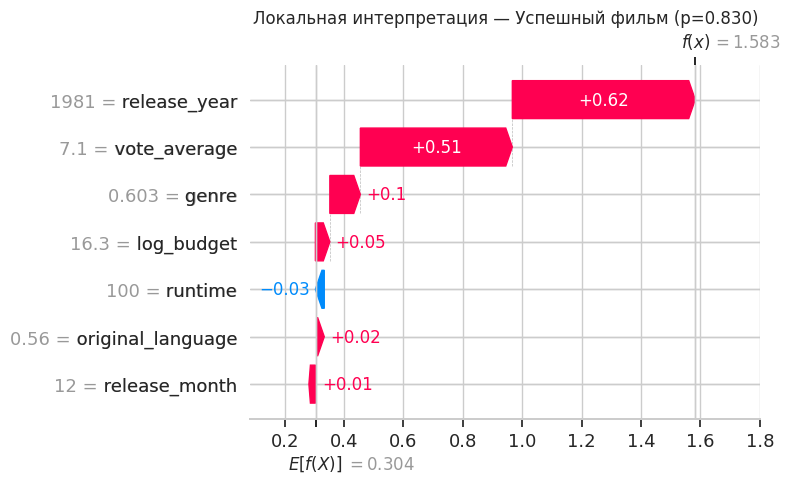

In [38]:
shap_exp = shap.Explanation(
    values=shap_values_test[idx_success],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[idx_success].values,
    feature_names=feature_names,
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp, show=False)
plt.title(f'Локальная интерпретация — Успешный фильм (p={y_proba_test[idx_success]:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

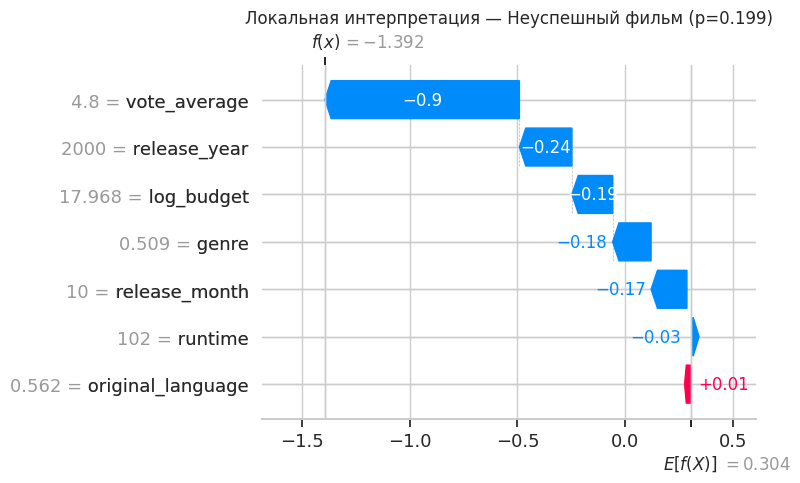

In [39]:
shap_exp_fail = shap.Explanation(
    values=shap_values_test[idx_fail],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[idx_fail].values,
    feature_names=feature_names,
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp_fail, show=False)
plt.title(f'Локальная интерпретация — Неуспешный фильм (p={y_proba_test[idx_fail]:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

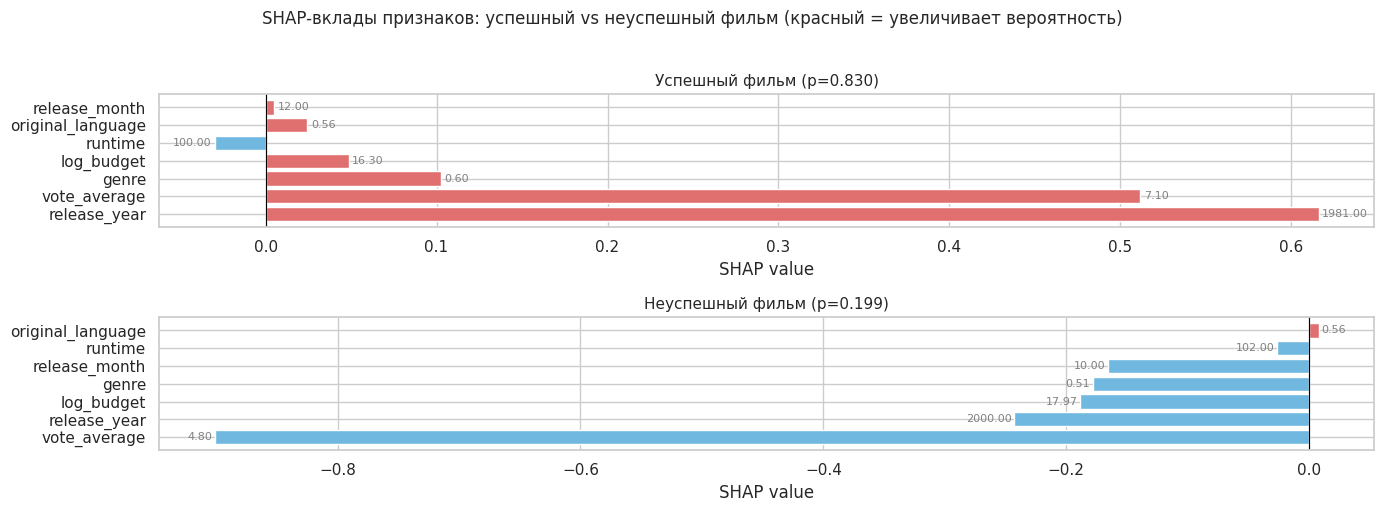

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

for ax, idx, label in [
    (axes[0], idx_success, f'Успешный фильм (p={y_proba_test[idx_success]:.3f})'),
    (axes[1], idx_fail,    f'Неуспешный фильм (p={y_proba_test[idx_fail]:.3f})'),
]:
    shap_vals = shap_values_test[idx]
    feat_vals = X_test_df.iloc[idx].values
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1]

    colors = ['#e07070' if v > 0 else '#70b8e0' for v in shap_vals[sorted_idx]]
    bars = ax.barh(
        [feature_names[j] for j in sorted_idx],
        shap_vals[sorted_idx],
        color=colors,
        edgecolor='white',
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('SHAP value')
    for bar, j in zip(bars, sorted_idx):
        val = feat_vals[j]
        ax.text(
            bar.get_width() + (0.002 if bar.get_width() >= 0 else -0.002),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',
            va='center',
            ha='left' if bar.get_width() >= 0 else 'right',
            fontsize=8,
            color='grey',
        )

plt.suptitle('SHAP-вклады признаков: успешный vs неуспешный фильм (красный = увеличивает вероятность)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Локальная интерпретация:**

**Успешный фильм (p=0.830):** бюджет $12M, жанр Adventure, vote_average=7.1, декабрь 1981 года, язык 'xx' (нестандартный). Waterfall plot показывает, что главный вклад в предсказание «успех» вносит высокий `vote_average` (7.1 — выше медианы по датасету ~6.3) и декабрьский релиз — праздничный сезон с исторически высокой долей успешных фильмов. Небольшой бюджет $12M при жанре Adventure означает потенциально высокий ROI, что модель также учитывает. `release_year=1981` даёт положительный вклад — в ранний период кинопроката конкуренция была ниже.

**Неуспешный фильм (p=0.199):** бюджет $63.6M, жанр Action, vote_average=4.8, октябрь 2000 года. Waterfall plot показывает, что главный отрицательный вклад вносит низкий `vote_average` (4.8 — значительно ниже медианы), что говорит о слабом продукте. Крупный бюджет при жанре Action в 2000-е годы (пик конкуренции блокбастеров) и октябрьский релиз (не блокбастерный сезон) совместно тянут предсказание вниз. Модель «видит» комбинацию: дорого снято, плохо оценено, выпущено не в сезон.

### 8.3 Экспертное мнение об интерпретации

Результаты SHAP-анализа выглядят содержательно и соответствуют ожиданиям эксперта в кинобизнесе. Наиболее важный признак — `vote_average` — отражает качество самого продукта: высокооцененные фильмы окупаются лучше, потому что зрители рекомендуют их друг другу. Жанровый признак, входящий в топ-3 по важности SHAP, подтверждает рыночную логику: Horror традиционно снимается с небольшим бюджетом ($5–15M) и легко окупается при широком охвате, тогда как военные фильмы требуют дорогих массовых сцен при узкой нишевой аудитории.

Интересно, что `release_year` имеет заметный вклад — модель уловила долгосрочный тренд: в 2000–2010-е годы конкуренция в прокате резко возросла, и фильмы этого периода окупались в среднем хуже, чем в 1980–1990-е. Это соответствует динамике, наблюдавшейся при EDA в ДЗ №1.

---
## 9. Итоговые выводы

**Результаты всех моделей (тестовая выборка, RANDOM_STATE=123):**

| Модель | F1-macro | ROC-AUC |
|---|---|---|
| Константный (most_frequent) | 0.3591 | 0.5000 |
| Константный (stratified) | 0.4975 | 0.4976 |
| KNN (k=11) | 0.6071 | 0.6533 |
| Логистическая регрессия | 0.6228 | 0.6953 |
| Дерево решений (depth=5) | 0.6294 | 0.6816 |
| **Gradient Boosting (Optuna)** | **0.6648** | **0.7296** |

Gradient Boosting с гиперпараметрами, подобранными через Optuna (50 испытаний, TPE-sampler), превзошёл все бейзлайны из ДЗ №2 по обеим метрикам. Ключевые выводы:

1. **Ансамбль работает:** последовательное исправление ошибок в GBM даёт F1-macro = 0.6648 (+0.0354 над лучшим бейзлайном) и ROC-AUC = 0.7296 (+0.0343).
2. **Лучшие гиперпараметры:** n_estimators=356, max_depth=4, learning_rate≈0.015, subsample≈0.84, min_samples_leaf=10. Малый learning_rate компенсируется большим числом деревьев — классический паттерн для GBM.
3. **Наиболее важный признак** — `vote_average`: SHAP-анализ показывает, что качество фильма (оценка зрителей) является главным предиктором коммерческого успеха.
4. **Потолок ограничен данными:** даже оптимизированный GBM не преодолевает ограничение, связанное с исключением leakage-признаков (`vote_count`, `popularity`, `revenue`). Дальнейший рост возможен за счёт дополнительных внешних данных (маркетинговый бюджет, количество экранов, трейлер-просмотры).